# Development of the Daily Report (BI Panel)

In [1]:
%load_ext autoreload
%autoreload 2

import logging

import geopandas as gpd
import xarray as xr

from mergedownloader.downloader import Downloader
from mergedownloader.file_downloader import ConnectionType, DownloadMode, FileDownloader
from mergedownloader.inpeparser import INPE_SERVER, InpeParsers, InpeTypes
from mergedownloader.utils import GISUtil

In [2]:
download_folder = "/workspaces/reports_folder/downloads/"

In [3]:
file_downloader = FileDownloader(
    server=INPE_SERVER,
    connection_type=ConnectionType.HTTP,
    download_mode=DownloadMode.NO_UPDATE,
    log_level=logging.DEBUG,
)

# Create a downloader instance
downloader = Downloader(
    file_downloader=file_downloader,
    parsers=InpeParsers,
    local_folder="/workspaces/reports_folder/downloads",
    log_level=logging.DEBUG,
)

Using wget through HTTP on: ftp.cptec.inpe.br


## Create the daily series

In [4]:
from datetime import datetime, timedelta
today = datetime.now()

In [5]:
start = today - timedelta(days=30)
end = today

start, end

(datetime.datetime(2026, 1, 7, 18, 52, 5, 824003),
 datetime.datetime(2026, 2, 6, 18, 52, 5, 824003))

In [6]:
# We can ask downloader to give us an entire cube of daily values (30 days back from 2026-01-01)
cube = downloader.create_cube(
    start_date=start,
    end_date=end,
    datatype=InpeTypes.DAILY_RAIN,
)

/usr/local/lib/python3.10/dist-packages/ecmwflibs/__init__.py:81: UserWarning: libglib-2.0.so.0: cannot open shared object file: No such file or directory
  warnings.warn(str(e))


In [7]:
cube["time"].to_series()

time
2026-01-07 12:00:00   2026-01-07 12:00:00
2026-01-08 12:00:00   2026-01-08 12:00:00
2026-01-09 12:00:00   2026-01-09 12:00:00
2026-01-10 12:00:00   2026-01-10 12:00:00
2026-01-11 12:00:00   2026-01-11 12:00:00
2026-01-12 12:00:00   2026-01-12 12:00:00
2026-01-13 12:00:00   2026-01-13 12:00:00
2026-01-14 12:00:00   2026-01-14 12:00:00
2026-01-15 12:00:00   2026-01-15 12:00:00
2026-01-16 12:00:00   2026-01-16 12:00:00
2026-01-17 12:00:00   2026-01-17 12:00:00
2026-01-18 12:00:00   2026-01-18 12:00:00
2026-01-19 12:00:00   2026-01-19 12:00:00
2026-01-20 12:00:00   2026-01-20 12:00:00
2026-01-21 12:00:00   2026-01-21 12:00:00
2026-01-22 12:00:00   2026-01-22 12:00:00
2026-01-23 12:00:00   2026-01-23 12:00:00
2026-01-24 12:00:00   2026-01-24 12:00:00
2026-01-25 12:00:00   2026-01-25 12:00:00
2026-01-26 12:00:00   2026-01-26 12:00:00
2026-01-27 12:00:00   2026-01-27 12:00:00
2026-01-28 12:00:00   2026-01-28 12:00:00
2026-01-29 12:00:00   2026-01-29 12:00:00
2026-01-30 12:00:00   2026-01

In [8]:
# DOwnload a cube with the forecast daily rain
forecast_cube = downloader.open_file(date=end, datatype=InpeTypes.DAILY_WRF)


In [9]:
forecast_cube["time"].to_series()

time
2026-02-06 12:00:00   2026-02-06 12:00:00
2026-02-07 12:00:00   2026-02-07 12:00:00
2026-02-08 12:00:00   2026-02-08 12:00:00
2026-02-09 12:00:00   2026-02-09 12:00:00
2026-02-10 12:00:00   2026-02-10 12:00:00
2026-02-11 12:00:00   2026-02-11 12:00:00
2026-02-12 12:00:00   2026-02-12 12:00:00
Name: time, dtype: datetime64[ns]

In [10]:
brazil = gpd.read_file("../data/states/")

<Axes: >

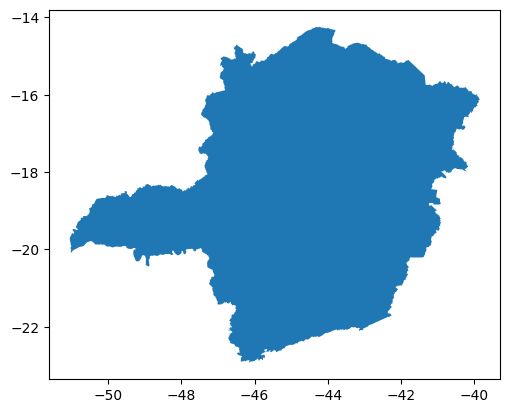

In [11]:
mg = brazil.query("SIGLA_UF == 'MG'")
mg.plot()

In [12]:
rain_mg = GISUtil.cut_cube_by_geoms(cube, mg.geometry)
forecast_mg = GISUtil.cut_cube_by_geoms(forecast_cube, mg.geometry)

Coverting shp CRS to EPSG:4326
Coverting shp CRS to EPSG:4326


In [13]:
rain_mg.shape, forecast_mg.shape

((31, 86, 111), (7, 123, 159))

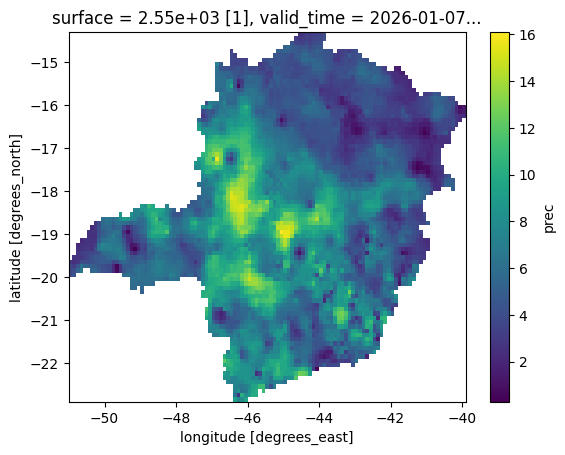

In [14]:
rain_mg.mean(dim="time").plot()

In [15]:
# forecast_mg = forecast_mg.rio.reproject_match(rain_mg)

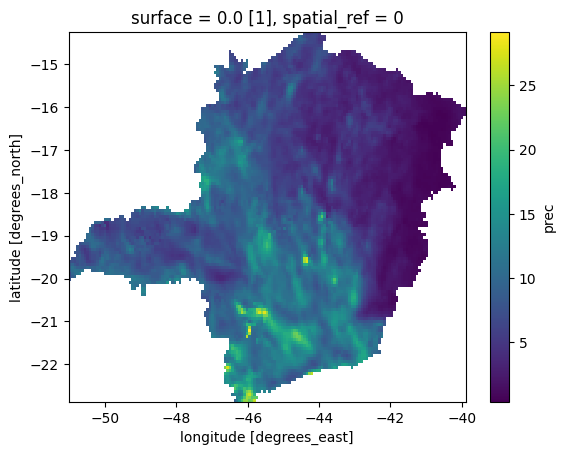

In [16]:
forecast_mg.mean(dim="time").plot()

In [17]:
rain_series = rain_mg.mean(dim=["latitude", "longitude"]).drop_vars("surface")

In [18]:
forecast_series = forecast_mg.mean(dim=["latitude", "longitude"]).drop_vars("surface")

In [19]:
from numpy import timedelta64

# adjust forecast_series time to zero hour
rain_series["time"] = rain_series["time"] - timedelta64(1, "D")

In [20]:
forecast_series.time

<xarray.DataArray 'time' (time: 7)>
array(['2026-02-06T12:00:00.000000000', '2026-02-07T12:00:00.000000000',
       '2026-02-08T12:00:00.000000000', '2026-02-09T12:00:00.000000000',
       '2026-02-10T12:00:00.000000000', '2026-02-11T12:00:00.000000000',
       '2026-02-12T12:00:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * time         (time) datetime64[ns] 2026-02-06T12:00:00 ... 2026-02-12T12:...
    spatial_ref  int64 0
Attributes:
    standard_name:  time
    long_name:      time

In [21]:
rain_series.time

<xarray.DataArray 'time' (time: 31)>
array(['2026-01-06T12:00:00.000000000', '2026-01-07T12:00:00.000000000',
       '2026-01-08T12:00:00.000000000', '2026-01-09T12:00:00.000000000',
       '2026-01-10T12:00:00.000000000', '2026-01-11T12:00:00.000000000',
       '2026-01-12T12:00:00.000000000', '2026-01-13T12:00:00.000000000',
       '2026-01-14T12:00:00.000000000', '2026-01-15T12:00:00.000000000',
       '2026-01-16T12:00:00.000000000', '2026-01-17T12:00:00.000000000',
       '2026-01-18T12:00:00.000000000', '2026-01-19T12:00:00.000000000',
       '2026-01-20T12:00:00.000000000', '2026-01-21T12:00:00.000000000',
       '2026-01-22T12:00:00.000000000', '2026-01-23T12:00:00.000000000',
       '2026-01-24T12:00:00.000000000', '2026-01-25T12:00:00.000000000',
       '2026-01-26T12:00:00.000000000', '2026-01-27T12:00:00.000000000',
       '2026-01-28T12:00:00.000000000', '2026-01-29T12:00:00.000000000',
       '2026-01-30T12:00:00.000000000', '2026-01-31T12:00:00.000000000',
       '2026-02-01T12:00:00.000000000', '2026-02-02T12:00:00.000000000',
       '2026-02-03T12:00:00.000000000', '2026-02-04T12:00:00.000000000',
       '2026-02-05T12:00:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * time         (time) datetime64[ns] 2026-01-06T12:00:00 ... 2026-02-05T12:...
    valid_time   datetime64[ns] ...
    spatial_ref  int64 0

In [22]:
forecast_series["time"] = forecast_series["time"] + timedelta64(12, "h")

In [23]:
# Get the DAILY AVERAGE RAIN to plot it here...
daily_average = downloader.create_cube(
    start_date="2026-01-04",
    end_date="2026-02-11",
    datatype=InpeTypes.DAILY_AVERAGE)

In [24]:
daily_average = GISUtil.cut_cube_by_geoms(daily_average, mg.geometry)

Coverting shp CRS to EPSG:4326


In [25]:
daily_avg_series = daily_average.mean(dim=["latitude", "longitude"])

In [26]:
delta_ns = rain_series["time"][0] - daily_avg_series["time"][0]
daily_avg_series["time"] = daily_avg_series["time"] + delta_ns

In [27]:
daily_avg_series["time"]

<xarray.DataArray 'time' (time: 39)>
array(['2026-01-06T12:00:00.000000000', '2026-01-07T12:00:00.000000000',
       '2026-01-08T12:00:00.000000000', '2026-01-09T12:00:00.000000000',
       '2026-01-10T12:00:00.000000000', '2026-01-11T12:00:00.000000000',
       '2026-01-12T12:00:00.000000000', '2026-01-13T12:00:00.000000000',
       '2026-01-14T12:00:00.000000000', '2026-01-15T12:00:00.000000000',
       '2026-01-16T12:00:00.000000000', '2026-01-17T12:00:00.000000000',
       '2026-01-18T12:00:00.000000000', '2026-01-19T12:00:00.000000000',
       '2026-01-20T12:00:00.000000000', '2026-01-21T12:00:00.000000000',
       '2026-01-22T12:00:00.000000000', '2026-01-23T12:00:00.000000000',
       '2026-01-24T12:00:00.000000000', '2026-01-25T12:00:00.000000000',
       '2026-01-26T12:00:00.000000000', '2026-01-27T12:00:00.000000000',
       '2026-01-28T12:00:00.000000000', '2026-01-29T12:00:00.000000000',
       '2026-01-30T12:00:00.000000000', '2026-01-31T12:00:00.000000000',
       '2026-02-01T12:00:00.000000000', '2026-02-02T12:00:00.000000000',
       '2026-02-03T12:00:00.000000000', '2026-02-04T12:00:00.000000000',
       '2026-02-05T12:00:00.000000000', '2026-02-06T12:00:00.000000000',
       '2026-02-07T12:00:00.000000000', '2026-02-08T12:00:00.000000000',
       '2026-02-09T12:00:00.000000000', '2026-02-10T12:00:00.000000000',
       '2026-02-11T12:00:00.000000000', '2026-02-12T12:00:00.000000000',
       '2026-02-13T12:00:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * time         (time) datetime64[ns] 2026-01-06T12:00:00 ... 2026-02-13T12:...
    spatial_ref  int64 0
    valid_time   datetime64[ns] ...

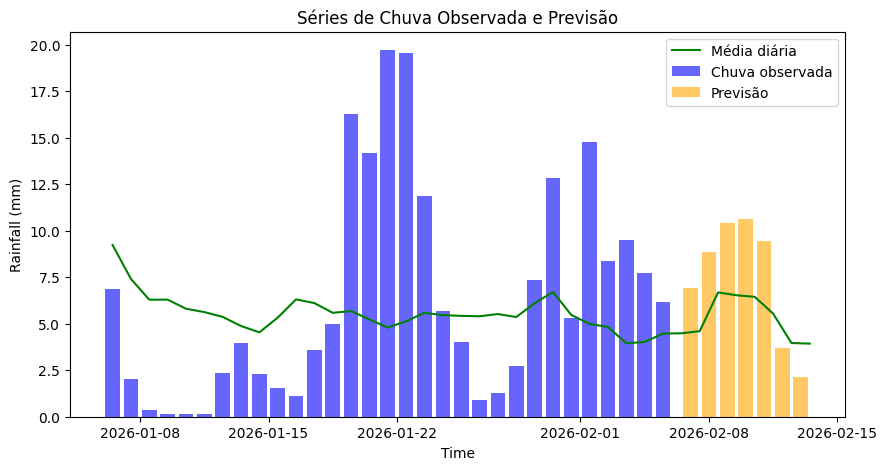

In [28]:
# Create a new plot. Plot rain_series and forecast_series together
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(rain_series.time, rain_series, label="Chuva observada", color="blue", alpha=0.6)
ax.bar(
    forecast_series.time,
    forecast_series,
    label="Previsão",
    color="orange",
    alpha=0.6,
)
ax.plot(daily_avg_series["time"], daily_avg_series, label="Média diária", color="green")
ax.set_title("Séries de Chuva Observada e Previsão")
ax.set_xlabel("Time")
ax.set_ylabel("Rainfall (mm)")
ax.legend()
plt.show()



In [29]:
import pandas as pd

rain_df = rain_series.to_dataframe()
rain_df["type"] = "Observed"

forecast_df = forecast_series.to_dataframe().drop(columns=["spatial_ref"])
forecast_df["type"] = "Forecast"

daily_avg_df = daily_avg_series.to_dataframe().drop(columns=["spatial_ref"])

# df = .drop(columns=["valid_time", "spatial_ref"])
df = pd.concat([rain_df, forecast_df], axis=0)
df = pd.concat([df, daily_avg_df], axis=1).drop(columns=["valid_time", "spatial_ref"])

In [30]:
df[["prec_acum", "pmed_acum"]] = df[["prec", "pmed"]].cumsum()
df

,prec,type,pmed,prec_acum,pmed_acum
time,,,,,
2026-01-06 12:00:00,6.843513,Observed,9.231080,6.843513,9.231080
2026-01-07 12:00:00,2.009686,Observed,7.407827,8.853200,16.638907
2026-01-08 12:00:00,0.385682,Observed,6.292084,9.238882,22.930992
2026-01-09 12:00:00,0.171215,Observed,6.294702,9.410097,29.225694
2026-01-10 12:00:00,0.157918,Observed,5.805363,9.568015,35.031056
2026-01-11 12:00:00,0.144323,Observed,5.626618,9.712337,40.657674
2026-01-12 12:00:00,2.364293,Observed,5.367357,12.076631,46.025032
2026-01-13 12:00:00,3.957545,Observed,4.876223,16.034176,50.901255
2026-01-14 12:00:00,2.304084,Observed,4.538828,18.338259,55.440082


In [31]:
df.index[-7]

Timestamp('2026-02-10 12:00:00')

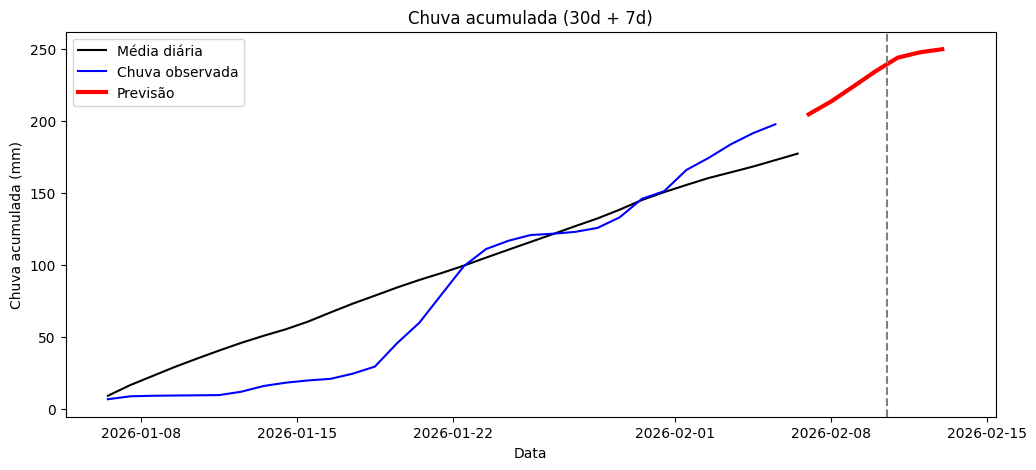

In [32]:
# From df, plot the pmed_acum in black,line (index is time) then plot prec_acum 
# (just the lines with type=observed) in blue and prec_acum (lines with type=forecast) in red.
fig, ax = plt.subplots(figsize=(12, 5))

# Plot pmed_acum (Average Accumulation)
ax.plot(df.index, df["pmed_acum"], color="black", label="Média diária")

# Plot Observed prec_acum
ax.plot(df.index, df["prec_acum"], color="blue", label="Chuva observada")

# Plot Forecast prec_acum
forecast_mask = df["type"] == "Forecast"
ax.plot(df.index[forecast_mask], df.loc[forecast_mask, "prec_acum"], color="red", label="Previsão", linewidth=3)

ax.set_title("Chuva acumulada (30d + 7d)")
ax.set_xlabel("Data")
ax.set_ylabel("Chuva acumulada (mm)")
ax.legend()

# Get current limits to prevent auto-scaling
# bottom, top = ax.get_ylim()
# ax.vlines(forecast_series["time"][0], bottom, top, color="gray", linestyle="--")
# ax.set_ylim(bottom, top)

# Alternative using axvline which spans the whole plot by default (0 to 1 in axes coords)
ax.axvline(df.index[-7], color="gray", linestyle="--")

In [33]:
2

2

<BarContainer object of 39 artists>

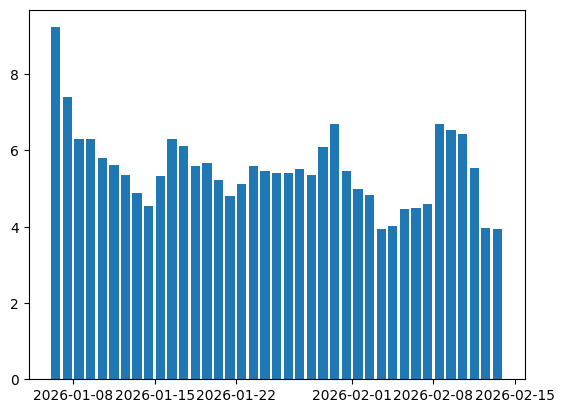

In [34]:
plt.bar(daily_avg_series["time"], daily_avg_series)

<BarContainer object of 7 artists>

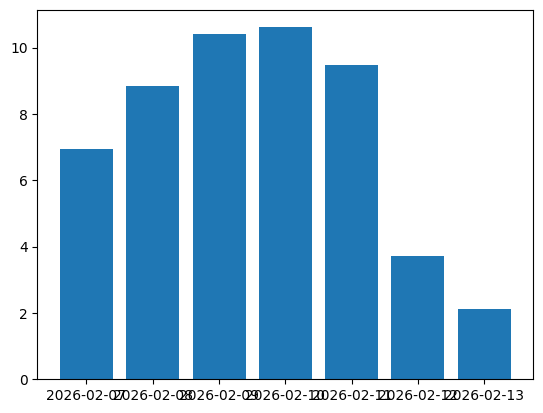

In [35]:
plt.bar(forecast_series["time"], forecast_series)

In [36]:
forecast_series["time"]

<xarray.DataArray 'time' (time: 7)>
array(['2026-02-07T00:00:00.000000000', '2026-02-08T00:00:00.000000000',
       '2026-02-09T00:00:00.000000000', '2026-02-10T00:00:00.000000000',
       '2026-02-11T00:00:00.000000000', '2026-02-12T00:00:00.000000000',
       '2026-02-13T00:00:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * time         (time) datetime64[ns] 2026-02-07 2026-02-08 ... 2026-02-13
    spatial_ref  int64 0

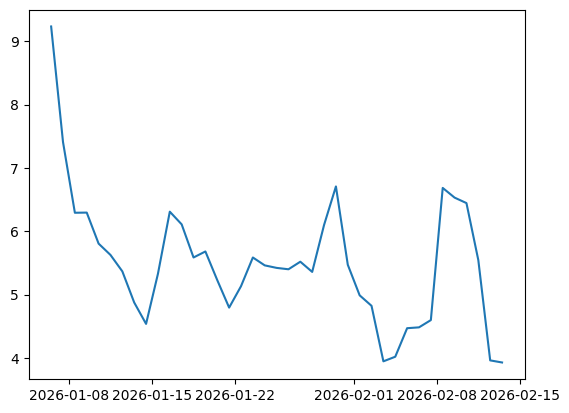

In [37]:
plt.plot(daily_avg_series["time"], daily_avg_series)

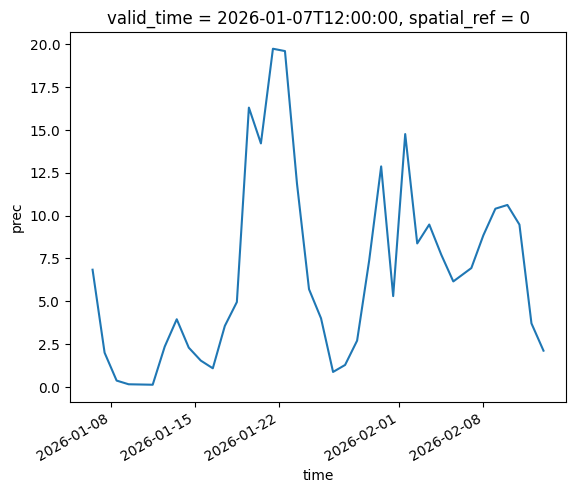

In [38]:
xr.concat([rain_series, forecast_series], dim="time").plot()

In [39]:
forecast_series

<xarray.DataArray 'prec' (time: 7)>
array([ 6.9390755,  8.847441 , 10.396416 , 10.614185 ,  9.470574 ,
        3.7170331,  2.1285675], dtype=float32)
Coordinates:
  * time         (time) datetime64[ns] 2026-02-07 2026-02-08 ... 2026-02-13
    spatial_ref  int64 0

In [40]:
xr.concat([rain_mg, forecast_mg], dim="time")

<xarray.DataArray 'prec' (time: 38, latitude: 209, longitude: 270)>
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], dtype=float32)
Coordinates:
  * latitude     (latitude) float64 -22.85 -22.83 -22.76 ... -14.35 -14.29
  * longitude    (longitude) float64 -50.98 -50.95 -50.91 ... -39.95 -39.92
  * time         (time) datetime64[ns] 2026-01-07T12:00:00 ... 2026-02-12T12:...
    surface      (time) float64 2.55e+03 2.55e+03 2.55e+03 ... 0.0 0.0 0.0
    valid_time   datetime64[ns] ...
    spatial_ref  int64 0
Attributes: (12/29)
    GRIB_paramId:                             260138
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      924924
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_name:                                Precipitation
    GRIB_shortName:                           prec
    GRIB_units:                               kg m**-2
    long_name:                                Precipitation
    units:                                    kg m**-2
    standard_name:                            unknown

In [41]:
# convert "2026-02-01" to datetime
from datetime import datetime

forecast_date = datetime.strptime("2026-02-01", "%Y-%m-%d")
forecast_date

datetime.datetime(2026, 2, 1, 0, 0)

In [42]:
import numpy as np

In [43]:
# Let's get 24h forecast data for that date
from datetime import timedelta


arrays = []
for i in range(50):
    forecast_datetime = forecast_date + timedelta(hours=i)
    arrays.append(
        downloader.open_file(
            date=forecast_date,
            datatype=InpeTypes.HOURLY_WRF,
            forecast_datetime=forecast_datetime,
        )
    )

TypeError: DateProcessor.normalize_date() got an unexpected keyword argument 'format'

In [ ]:
print(f"Printing WRF hourly forecast means for {forecast_date}")
for array in arrays:
    forecast_datetime = pd.to_datetime(array.valid_time.item())
    print(f"Forecast for {forecast_datetime}: {array.mean().item()}")

Printing WRF hourly forecast means for 2026-02-01 00:00:00
Forecast for 2026-02-01 00:00:00: 0.0
Forecast for 2026-02-01 01:00:00: 0.06418007612228394
Forecast for 2026-02-01 02:00:00: 0.1866171509027481
Forecast for 2026-02-01 03:00:00: 0.3323465883731842
Forecast for 2026-02-01 04:00:00: 0.49323177337646484
Forecast for 2026-02-01 05:00:00: 0.6630695462226868
Forecast for 2026-02-01 06:00:00: 0.8417037129402161
Forecast for 2026-02-01 07:00:00: 1.0344793796539307
Forecast for 2026-02-01 08:00:00: 1.2331445217132568
Forecast for 2026-02-01 09:00:00: 1.4319099187850952
Forecast for 2026-02-01 10:00:00: 1.6273696422576904
Forecast for 2026-02-01 11:00:00: 1.8204138278961182
Forecast for 2026-02-01 12:00:00: 2.008195638656616
Forecast for 2026-02-01 13:00:00: 2.193913221359253
Forecast for 2026-02-01 14:00:00: 2.386296510696411
Forecast for 2026-02-01 15:00:00: 2.5941786766052246
Forecast for 2026-02-01 16:00:00: 2.8271188735961914
Forecast for 2026-02-01 17:00:00: 3.075165033340454
Fore

In [ ]:
forecast_cube.time

<xarray.DataArray 'time' (time: 8)>
array(['2026-02-01T00:00:00.000000000', '2026-02-02T00:00:00.000000000',
       '2026-02-03T00:00:00.000000000', '2026-02-04T00:00:00.000000000',
       '2026-02-05T00:00:00.000000000', '2026-02-06T00:00:00.000000000',
       '2026-02-07T00:00:00.000000000', '2026-02-08T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
    surface      float64 ...
    spatial_ref  int64 ...
  * time         (time) datetime64[ns] 2026-02-01 2026-02-02 ... 2026-02-08
Attributes:
    standard_name:  time
    long_name:      time

In [ ]:
cube.time

<xarray.DataArray 'time' (time: 30)>
array(['2026-01-01T12:00:00.000000000', '2026-01-02T12:00:00.000000000',
       '2026-01-03T12:00:00.000000000', '2026-01-04T12:00:00.000000000',
       '2026-01-05T12:00:00.000000000', '2026-01-06T12:00:00.000000000',
       '2026-01-07T12:00:00.000000000', '2026-01-08T12:00:00.000000000',
       '2026-01-09T12:00:00.000000000', '2026-01-10T12:00:00.000000000',
       '2026-01-11T12:00:00.000000000', '2026-01-12T12:00:00.000000000',
       '2026-01-13T12:00:00.000000000', '2026-01-14T12:00:00.000000000',
       '2026-01-15T12:00:00.000000000', '2026-01-16T12:00:00.000000000',
       '2026-01-17T12:00:00.000000000', '2026-01-18T12:00:00.000000000',
       '2026-01-19T12:00:00.000000000', '2026-01-20T12:00:00.000000000',
       '2026-01-21T12:00:00.000000000', '2026-01-22T12:00:00.000000000',
       '2026-01-23T12:00:00.000000000', '2026-01-24T12:00:00.000000000',
       '2026-01-25T12:00:00.000000000', '2026-01-26T12:00:00.000000000',
       '2026-01-27T12:00:00.000000000', '2026-01-28T12:00:00.000000000',
       '2026-01-29T12:00:00.000000000', '2026-01-30T12:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time         (time) datetime64[ns] 2026-01-01T12:00:00 ... 2026-01-30T12:...
    surface      float64 ...
    valid_time   datetime64[ns] ...
    spatial_ref  int64 0
Attributes:
    long_name:      initial time of forecast
    standard_name:  forecast_reference_time